In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from wordcloud import WordCloud, STOPWORDS

In [2]:
df = pd.read_csv("../data/emotions_improved.csv")
df.head()

,text,emotion
0,"Eu fui criada para ajudar as pessoas, e é isso...",happy
1,Sinto que minha existência tem um propósito ma...,happy
2,O sentido da minha vida como robô é tornar a v...,happy
3,Acredito que a tecnologia pode ser uma ferrame...,happy
4,Ver as pessoas felizes e satisfeitas com o que...,happy


In [3]:
df.describe()

,text,emotion
count,1266058,1258797
unique,1253988,7
top,,neutral
freq,448,330972


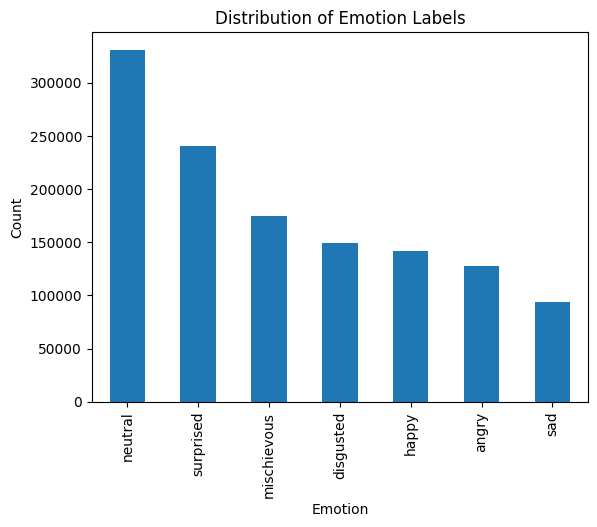

emotion
neutral        0.262927
surprised      0.190943
mischievous    0.138505
disgusted      0.118875
happy          0.112770
angry          0.101481
sad            0.074497
Name: proportion, dtype: float64


In [4]:
df["emotion"].value_counts().plot(kind="bar")
plt.title("Distribution of Emotion Labels")
plt.xlabel("Emotion")
plt.ylabel("Count")
plt.show()

print(df["emotion"].value_counts(normalize=True))

In [5]:
df.isnull().sum()

text        107
emotion    7368
dtype: int64

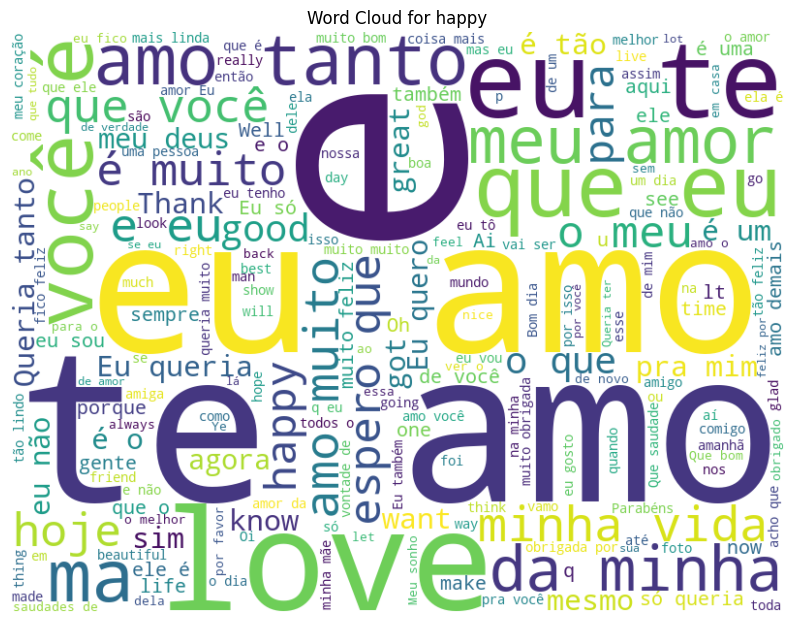

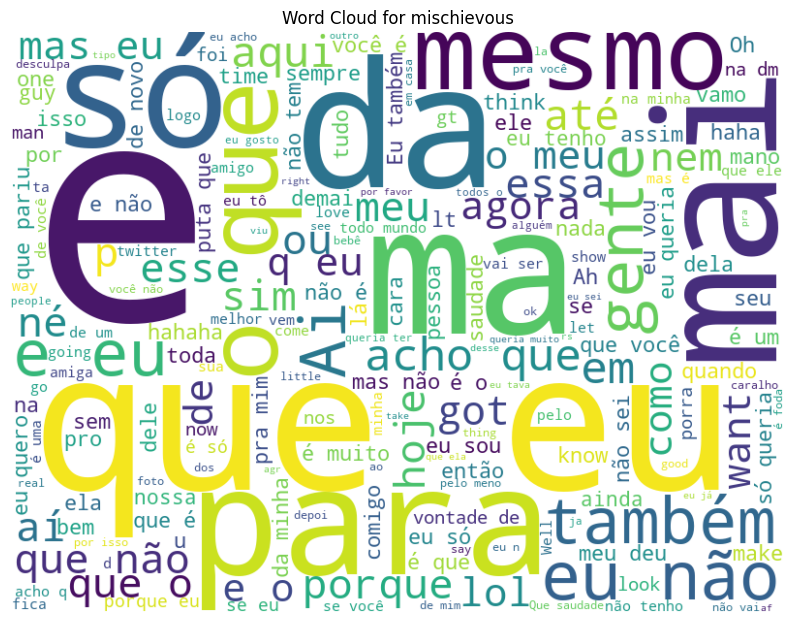

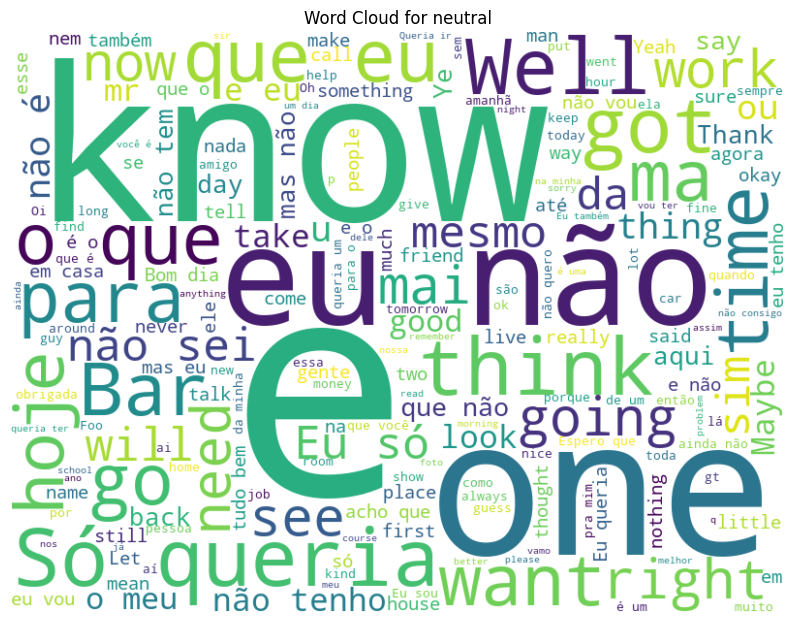

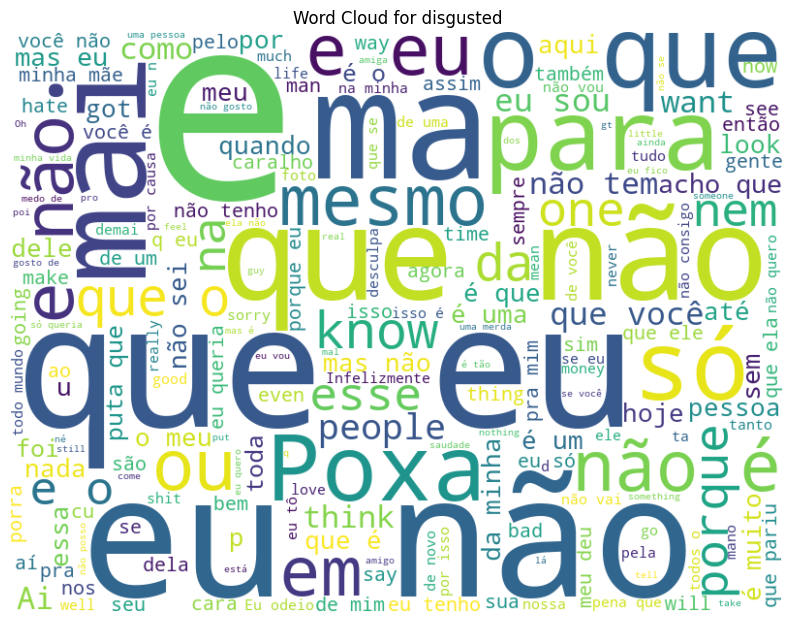

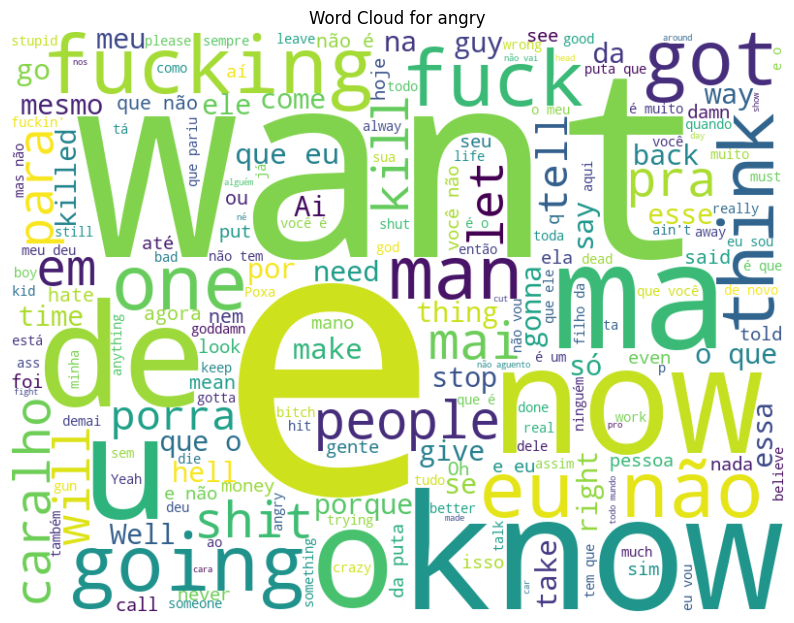

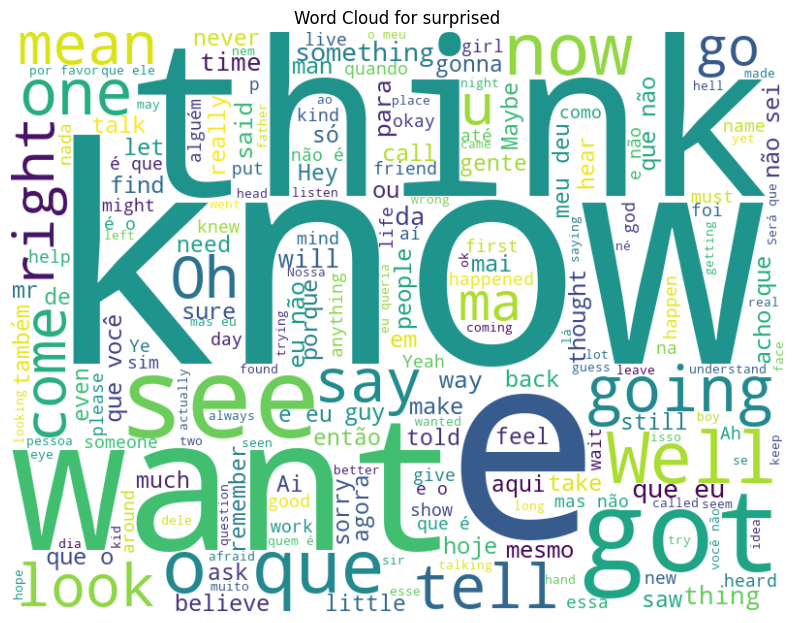

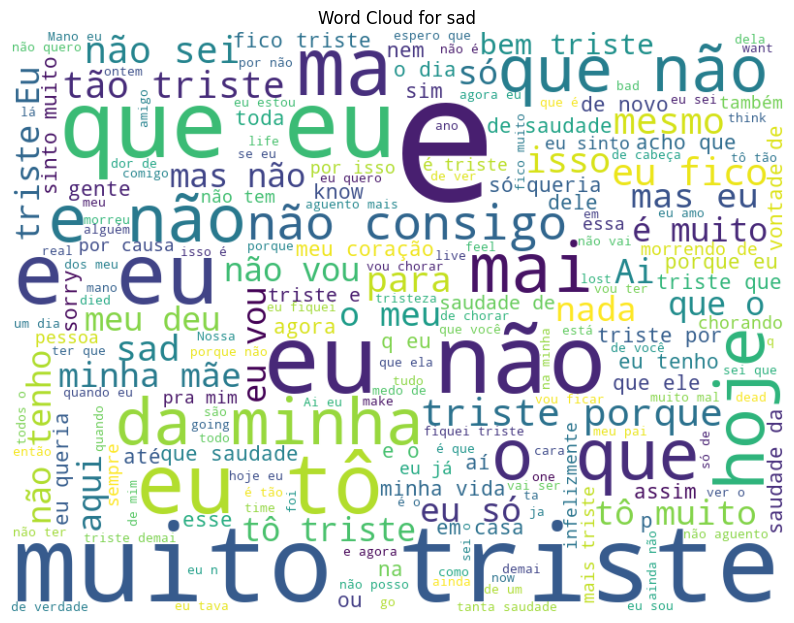

No valid text found for emotion: nan


In [6]:
for emotion in df["emotion"].unique():
    emotion_texts = df[df["emotion"] == emotion]["text"].dropna().astype(str)
    text = " ".join(emotion_texts)
    if text.strip():
        wordcloud = WordCloud(stopwords=STOPWORDS, background_color="white", width=800, height=600).generate(text)
        plt.figure(figsize=(10, 8))
        plt.imshow(wordcloud, interpolation="bilinear")
        plt.axis("off")
        plt.title(f"Word Cloud for {emotion}")
        plt.show()
    else:
        print(f"No valid text found for emotion: {emotion}")